# 01: Lineær regresjon fra bunnen av
Data Mining & Analytics – Samling 2, dag 2 (regresjon)


In [ ]:
import os
os.environ["LOKY_MAX_CPU_COUNT"] = "4"
import warnings
warnings.filterwarnings("ignore", category=FutureWarning)

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from scipy import stats

sns.set_theme(style="whitegrid", context="notebook")
plt.rcParams["figure.figsize"] = (8, 4.5)
rng = np.random.default_rng(42)

## Enkel lineær regresjon

Modell: $y = \beta_0 + \beta_1 x + \varepsilon$. 

OLS minimerer $\sum_i (y_i - \hat{y}_i)^2$ og har løsningen:

$$ \hat{\boldsymbol\beta} = (\boldsymbol X^T \boldsymbol X)^{-1} \boldsymbol X^T \boldsymbol y $$

β (manuell): [2.846 2.023]
β (sklearn):  [2.846 2.023]


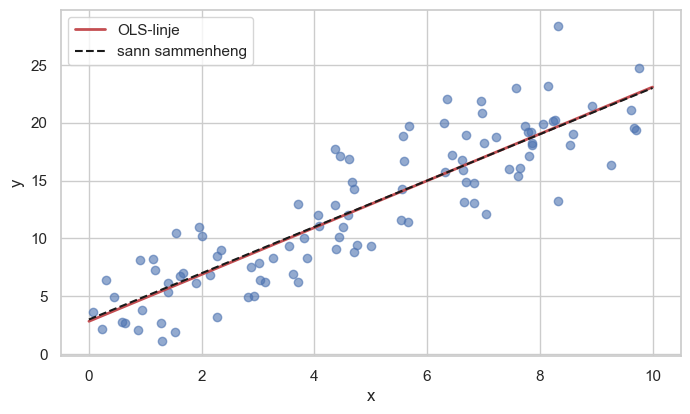

In [ ]:
from sklearn.linear_model import LinearRegression

n = 100
x = rng.uniform(0, 10, n)
y = 3.0 + 2.0 * x + rng.normal(0, 3, n) 

X = np.c_[np.ones(n), x] # β0
beta = np.linalg.solve(X.T @ X, X.T @ y)          
print("β (manuell):", beta.round(3))


lr = LinearRegression().fit(x.reshape(-1, 1), y)
print("β (sklearn): ", np.r_[lr.intercept_, lr.coef_].round(3))

plt.scatter(x, y, alpha=0.6)
xs = np.linspace(0, 10, 50)
plt.plot(xs, beta[0] + beta[1] * xs, "r", lw=2, label="OLS-linje")
plt.plot(xs, 3 + 2 * xs, "k--", label="sann sammenheng")
plt.legend()
plt.xlabel("x")
plt.ylabel("y")
plt.show()

Residualene (feilene) $e_i = y_i - \hat y_i$ er avstandene OLS minimerer (kvadrert)

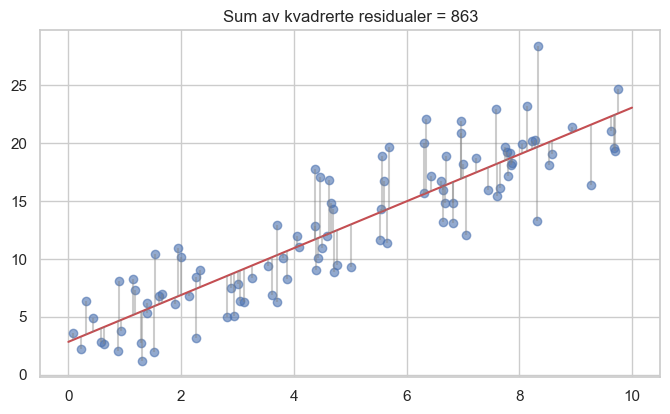

In [3]:
yhat = X @ beta
plt.scatter(x, y, alpha=0.6)
plt.plot(xs, beta[0] + beta[1] * xs, "r")
plt.vlines(x, y, yhat, color="gray", alpha=0.4)
plt.title(f"Sum av kvadrerte residualer = {((y - yhat)**2).sum():.0f}")
plt.show()

## Multippel lineær regresjon

Samme metode med flere variabler: $y = \beta_0 + \beta_1 x_1 + \dots + \beta_p x_p + \varepsilon$.


## Metrikker

| Metrikk | Formel | Enhet |
|---|---|---|
| MAE | $\frac1n\sum \lvert y_i-\hat y_i\rvert$ | samme som y |
| MSE | $\frac1n\sum (y_i-\hat y_i)^2$ | y² |
| RMSE | $\sqrt{\text{MSE}}$ | samme som y (straffer store feil mer enn MAE) |
| R² | $1-\frac{\sum (y_i-\hat y_i)^2}{\sum (y_i-\bar y)^2}$ | uten enhet; 1 = perfekt, 0 = like bra som å gjette gjennomsnittet |


In [ ]:
from sklearn.model_selection import train_test_split
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score

def evaluer(y_sann, y_pred):
    return {"MAE": mean_absolute_error(y_sann, y_pred),
            "RMSE": np.sqrt(mean_squared_error(y_sann, y_pred)),
            "R2": r2_score(y_sann, y_pred)}

x_train, x_test, y_train, y_test = train_test_split(x.reshape(-1, 1), y, test_size=0.25, random_state=0)
lr = LinearRegression().fit(x_train, y_train)
print("Trening:", {k: round(v, 2) for k, v in evaluer(y_train, lr.predict(x_train)).items()})
print("Test:   ", {k: round(v, 2) for k, v in evaluer(y_test, lr.predict(x_test)).items()})
print("Baseline (gjetter gjennomsnittet):", {k: round(v, 2) for k, v in evaluer(y_test, np.full_like(y_test, y_train.mean())).items()})

Trening: {'MAE': 2.38, 'RMSE': np.float64(2.97), 'R2': 0.79}
Test:    {'MAE': 2.37, 'RMSE': np.float64(2.86), 'R2': 0.71}
Baseline (gjett gjennomsnittet): {'MAE': 5.13, 'RMSE': np.float64(5.8), 'R2': -0.19}


## polynomregresjon, under- og overtilpasning


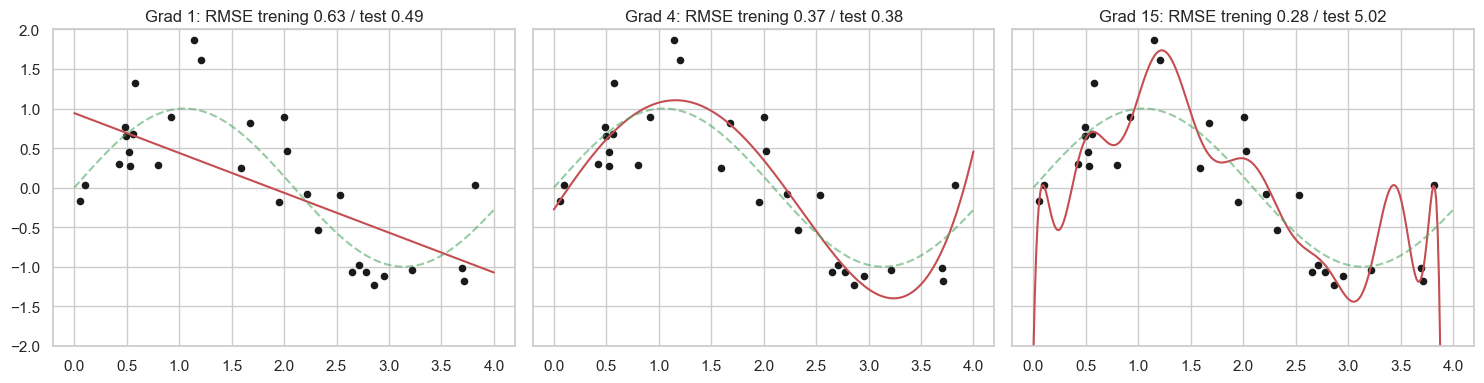

In [ ]:
from sklearn.preprocessing import PolynomialFeatures
from sklearn.pipeline import make_pipeline

def f_sann(x):
    """
    En funksjon som gererer treningsdata basert på x-verdier
    """
    return np.sin(1.5 * x)

x_train = rng.uniform(0, 4, 30)
y_train = f_sann(x_train) + rng.normal(0, 0.3, 30)

x_test = rng.uniform(0, 4, 200)
y_test = f_sann(x_test) + rng.normal(0, 0.3, 200)

xs = np.linspace(0, 4, 300)

fig, axes = plt.subplots(1, 3, figsize=(15, 4), sharey=True)
for ax, grad in zip(axes, [1, 4, 15]):
    mod = make_pipeline(PolynomialFeatures(grad), LinearRegression()).fit(x_train.reshape(-1, 1), y_train)
    rmse_tr = np.sqrt(mean_squared_error(y_train, mod.predict(x_train.reshape(-1, 1))))
    rmse_te = np.sqrt(mean_squared_error(y_test, mod.predict(x_test.reshape(-1, 1))))
    ax.scatter(x_train, y_train, color="k", s=20)
    ax.plot(xs, mod.predict(xs.reshape(-1, 1)), "r")
    ax.plot(xs, f_sann(xs), "g--", alpha=0.6)
    ax.set_ylim(-2, 2)
    ax.set_title(f"Grad {grad}: RMSE trening {rmse_tr:.2f} / test {rmse_te:.2f}")
plt.tight_layout()
plt.show()

* **Grad 1** – *undertilpasning* (høy bias): for enkel til å fange mønsteret; dårlig både på trening og test.
* **Grad 4** – passe.
* **Grad 15** – *overtilpasning* (høy varians): tilpasser støyen; svært lav treningsfeil, høy testfeil.

## Gradient descent

For mer kompliserte modeller kan vi ikke alltid bruke en deterministisk løsning. Gradient descent tar små steg nedover tapsfunksjonen:

$$ \boldsymbol\beta \leftarrow \boldsymbol\beta - \eta \,\nabla_{\boldsymbol\beta} L $$

der η er læringsraten (et hyperparameter).

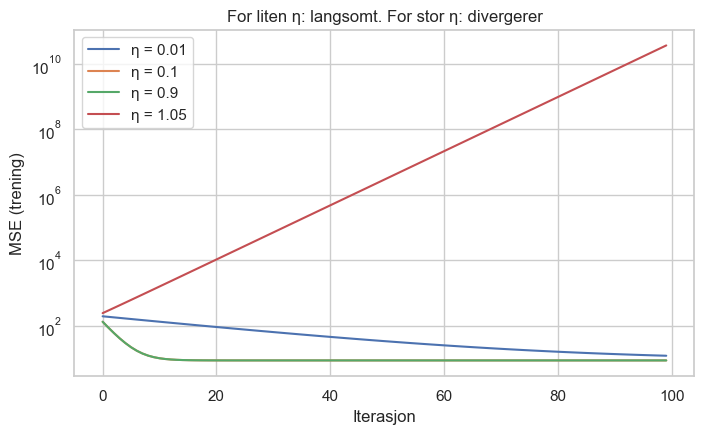

GD-løsning (standardisert x): [12.692  5.508]   OLS (standardisert x): [12.692  5.508]


In [ ]:
xs_ = (x - x.mean()) / x.std()                 # standardiser -> gir mer stabil læring for Gradient decent
Xs = np.c_[np.ones(len(xs_)), xs_]

def gd(X, y, eta, iter=100):
    b = np.zeros(X.shape[1]); tap = []
    for _ in range(iter):
        grad = 2 / len(y) * X.T @ (X @ b - y)
        b = b - eta * grad
        tap.append(np.mean((X @ b - y) ** 2))
    return b, tap

for eta in [0.01, 0.1, 0.9, 1.05]:
    b, tap = gd(Xs, y, eta)
    plt.plot(tap, label=f"η = {eta}")
plt.yscale("log"); plt.xlabel("Iterasjon")
plt.ylabel("MSE (trening)")
plt.legend()
plt.title("For liten η: langsomt. For stor η: divergerer")
plt.show()

b, _ = gd(Xs, y, 0.1, 500)
print("GD-løsning (standardisert x):", b.round(3), "  OLS (standardisert x):", np.linalg.solve(Xs.T @ Xs, Xs.T @ y).round(3))